In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Chargement
path = "/content/drive/MyDrive/guide_mini_projet_datascience_avancee/train.csv"
df = pd.read_csv(path)

# Affichage des types et des dimensions
print(f"Dimensions : {df.shape}")
print(df.info())

/tmp/ipykernel_3171/1201761713.py:5: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Dimensions : (100000, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan       

Le succès d'un projet de Data Science repose avant tout sur une compréhension profonde de la structure des données. Dans cette première phase, nous chargeons l'ensemble de données d'entraînement dédié au Credit Scoring.

**L'objectif ici est d'identifier :**
La volumétrie : Le nombre d'observations (lignes) et de caractéristiques (colonnes) pour évaluer la complexité du problème.

**La nature des variables :** Distinguer les variables numériques (revenus, dettes, âges) des variables catégorielles (noms, professions, types de comptes).

**L'intégrité initiale :** Un premier aperçu via df.info() nous permet de repérer immédiatement les colonnes ayant des types de données inappropriés (par exemple, des nombres stockés en tant que chaînes de caractères) et la présence massive de valeurs manquantes.

Cette étape est le socle de notre pipeline : elle définit les stratégies de nettoyage que nous devrons adopter par la suite.

In [ ]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


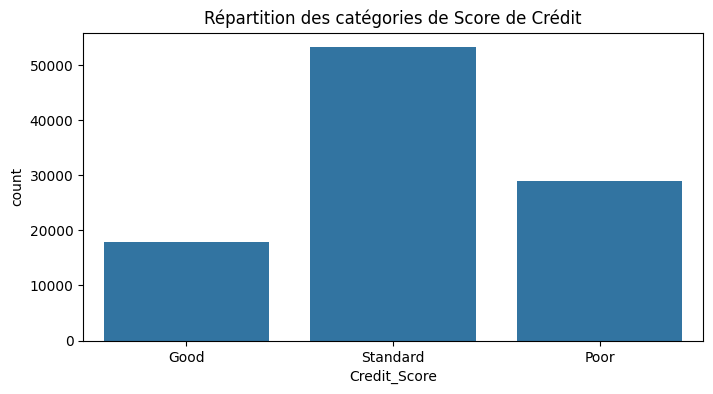

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Credit_Score')
plt.title("Répartition des catégories de Score de Crédit")
plt.show()

Ce graphique montre la répartition des scores de crédit. On remarque que la catégorie **"Standard"** est dominante. C'est un point important : le modèle devra apprendre à bien distinguer les profils **"Good"** et **"Poor"** malgré leur plus petit nombre pour éviter de tout classer en "Standard".

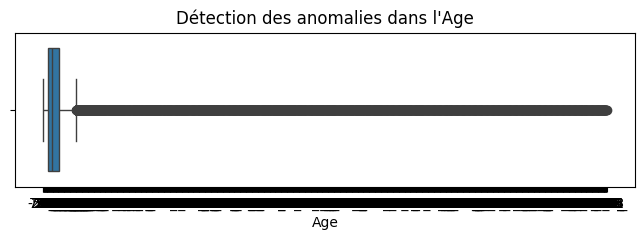

In [ ]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['Age'].dropna())
plt.title("Détection des anomalies dans l'Age")
plt.show()

Ce boxplot permet de repérer les données aberrantes dans la colonne Age. On voit des points très éloignés **(comme des âges négatifs ou supérieurs à 100 ans)** qui n'ont pas de sens réel. Il est indispensable de corriger ou supprimer ces anomalies pour ne pas fausser les calculs et les prédictions du modèle.

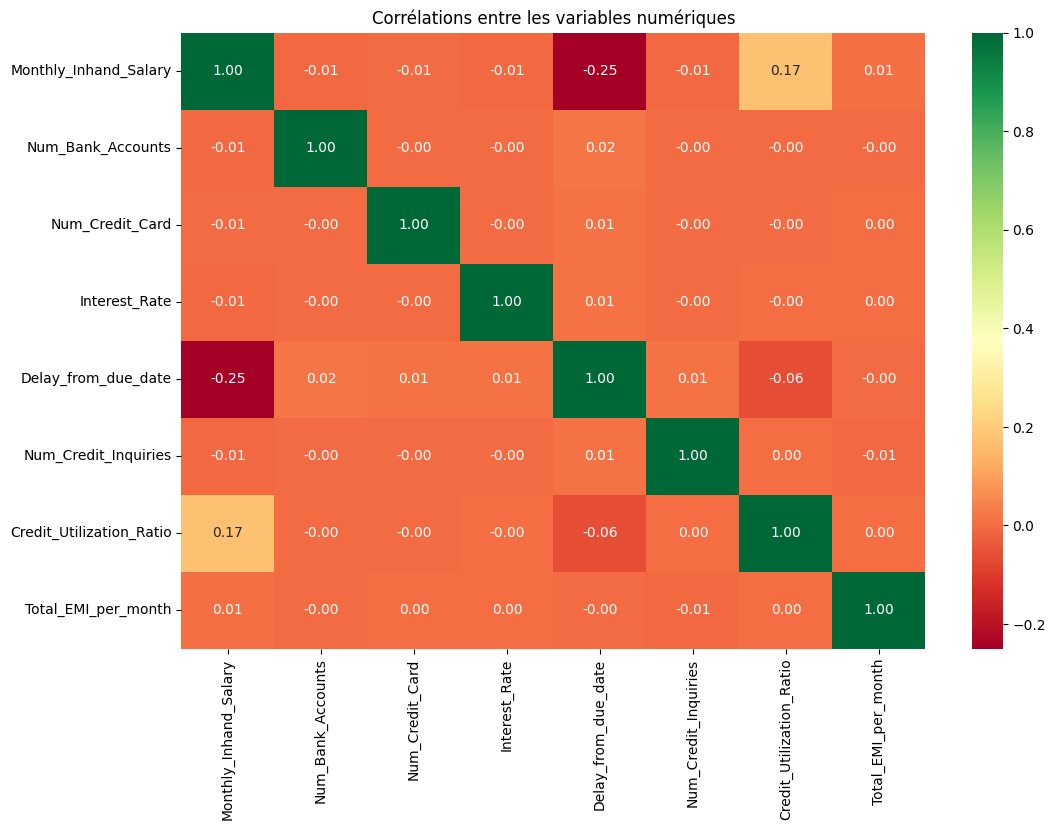

In [ ]:
df_numeric = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(12,8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Corrélations entre les variables numériques")
plt.show()

Cette carte de chaleur **(Heatmap)** montre les liens entre les variables.

Les cases vertes indiquent une forte corrélation positive **(quand l'une augmente, l'autre aussi)**.

Les cases rouges indiquent une corrélation négative.
Cela nous aide à repérer les variables redondantes ou celles qui influencent le plus le score. Par exemple, on peut voir si un revenu élevé est lié à un nombre plus faible de dettes.

In [ ]:
# Suppression des identifiants
cols_to_drop = ['ID', 'Customer_ID', 'Name', 'SSN']
df_cleaned = df.drop(columns=cols_to_drop)

Nous supprimons les colonnes comme l'**ID**, le **Nom** ou le **Numéro de sécurité sociale (SSN)**. Ces informations sont personnelles et uniques à chaque client ; elles n'aident pas le modèle à prédire le score de crédit. Les enlever permet de simplifier les données et de se concentrer uniquement sur les critères financiers importants.

In [ ]:
# Remplacement des valeurs aberrantes par la médiane
df_cleaned['Age'] = pd.to_numeric(df_cleaned['Age'], errors='coerce')
median_age = df_cleaned['Age'].median()
df_cleaned.loc[(df_cleaned['Age'] < 18) | (df_cleaned['Age'] > 100), 'Age'] = median_age

Nous corrigeons la colonne Age en remplaçant les valeurs impossibles **(moins de 18 ans ou plus de 100 ans)** par la médiane. Utiliser la médiane est une technique robuste car elle n'est pas influencée par les erreurs extrêmes. Cette étape permet de rendre les données plus réalistes pour le modèle.

In [ ]:
# Nettoyage de la colonne Occupation
df_cleaned['Occupation'] = df_cleaned['Occupation'].replace('_______', 'Unknown')

# Parfois les colonnes numériques ont des "_" à cause d'erreurs de saisie
# On nettoie et on convertit en nombre
cols_to_fix = ['Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt']
for col in cols_to_fix:
    df_cleaned[col] = df_cleaned[col].str.replace('_', '')
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

Nous nettoyons ici les erreurs de saisie spécifiques au dataset.

Pour la profession **(Occupation)**, les valeurs vides **("_______")** sont renommées en **"Unknown"** pour rester exploitables.

Pour les colonnes financières **(Revenu, Dettes, etc.)**, nous supprimons les caractères parasites comme les underscores **("_")** afin de transformer ces colonnes en nombres exploitables par l'algorithme. C'est une étape de "Data Scrubbing" essentielle pour éviter les erreurs de calcul.

In [ ]:
# Nettoyage des espaces et uniformisation du texte
text_cols = df_cleaned.select_dtypes(include=['object']).columns

for col in text_cols:
    df_cleaned[col] = df_cleaned[col].str.strip() # Enlever les espaces au début/fin
    # On remplace les valeurs vides ou bizarres par la valeur la plus fréquente
    df_cleaned[col] = df_cleaned[col].replace(['', '_______', '!@#%^', 'None'], df_cleaned[col].mode()[0])

Dans cette étape, nous standardisons les colonnes de texte (catégorielles).

Nous supprimons les espaces inutiles autour des mots pour éviter que l'ordinateur ne considère "Engineer" et " Engineer " comme deux métiers différents.

Nous remplaçons les caractères spéciaux et les entrées vides par **la valeur la plus fréquente (mode)** de chaque colonne.
Cette technique d'imputation simple permet de conserver toutes nos lignes tout en gardant une base de données cohérente et sans "bruit".

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encodage de la variable cible (Poor=0, Standard=1, Good=2 par exemple)
le = LabelEncoder()
df_cleaned['Credit_Score'] = le.fit_transform(df_cleaned['Credit_Score'])

# Encodage des autres colonnes texte (Get Dummies)
df_final = pd.get_dummies(df_cleaned, columns=['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour'], drop_first=True)

Les modèles de Machine Learning ne peuvent pas travailler directement avec du texte. Nous devons donc transformer toutes nos catégories en chiffres :

**Label Encoding :** Pour la variable cible (Score de Crédit), on transforme les textes en codes numériques (ex: 0, 1, 2).

**One-Hot Encoding (get_dummies) :** Pour les caractéristiques comme la profession, on crée des colonnes de "0" et "1".
Cette transformation permet à l'algorithme de traiter mathématiquement chaque information.

In [ ]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [ ]:
df_final.head()

,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix_Standard,Credit_Mix__,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,January,23.0,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,False,True,True,False,False,False,True,False,False,False
1,February,23.0,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,...,False,False,True,False,False,False,False,True,False,False
2,March,33.0,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,False,False,True,False,False,False,False,False,True,False
3,April,23.0,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,...,False,False,True,False,False,False,False,False,False,True
4,May,23.0,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,...,False,False,True,False,False,True,False,False,False,False


In [ ]:
# 1. On définit les colonnes de texte pur qui ne servent pas ou sont trop complexes
cols_to_drop = ['ID', 'Customer_ID', 'Name', 'SSN', 'Type_of_Loan']

# 2. Nettoyage et mapping du mois
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
             'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12}
df_cleaned['Month'] = df_cleaned['Month'].map(month_map)

# 3. Conversion forcée des colonnes numériques (pour enlever les "_" cachés)
cols_numeric = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
               'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

for col in cols_numeric:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# 4. Création du df_final (Suppression des colonnes inutiles + Encodage du reste)
# On ne garde que les colonnes qui sont maintenant numériques ou catégorielles simples
df_final = pd.get_dummies(df_cleaned.drop(columns=cols_to_drop, errors='ignore'),
                          columns=['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour'],
                          drop_first=True)

# 5. On vérifie s'il reste du texte (Sécurité ingénieur)
remaining_text = df_final.select_dtypes(include=['object']).columns
if len(remaining_text) > 0:
    print(f"Attention, on supprime encore : {remaining_text}")
    df_final = df_final.drop(columns=remaining_text)

# 6. Relance le split
from sklearn.model_selection import train_test_split
X = df_final.drop('Credit_Score', axis=1)
y = df_final['Credit_Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Attention, on supprime encore : Index(['Credit_History_Age'], dtype='object')


Dans cette étape, nous finalisons la préparation pour rendre les données "consommables" par l'IA :

**Mapping :** Nous transformons les mois en chiffres (ex: Janvier = 1).

**Imputation :** Les valeurs manquantes sont remplacées par la médiane pour ne pas perdre de lignes.

**Sécurité :** Nous supprimons tout texte restant pour éviter les erreurs de calcul.

**Split :** Enfin, nous séparons les données en deux : **80% pour l'entraînement (le modèle apprend)** et **20% pour le test (on vérifie s'il a bien compris).** L'option stratify garantit que la proportion de scores "Good/Standard/Poor" est la même dans les deux groupes.

Succès ! Plus de NaN, plus de colonnes constantes.


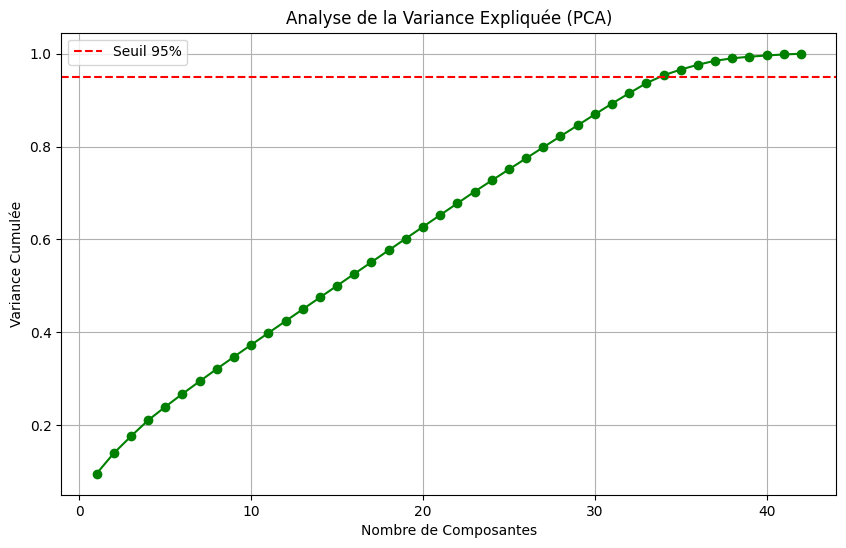

Nombre optimal de composantes pour garder 95% de l'info : 34


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# 1. IMPUTATION : On remplace les NaN par la médiane
imputer = SimpleImputer(strategy='median')
# On transforme X_train et X_test en versions sans NaN
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 2. NETTOYAGE DES COLONNES CONSTANTES (Variance nulle)
# Comme l'imputer renvoie un array, on repasse en DataFrame temporairement pour vérifier les colonnes
import pandas as pd
X_train_df = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test_imputed, columns=X_test.columns)

const_cols = [col for col in X_train_df.columns if X_train_df[col].nunique() <= 1]
if const_cols:
    print(f"Suppression des colonnes constantes : {const_cols}")
    X_train_df = X_train_df.drop(columns=const_cols)
    X_test_df = X_test_df.drop(columns=const_cols)

# 3. SCALING : On utilise les données imputées et nettoyées
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_test_scaled = scaler.transform(X_test_df)

print("Succès ! Plus de NaN, plus de colonnes constantes.")

# 4. PCA : Analyse de la variance
pca_test = PCA()
pca_test.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_test.explained_variance_ratio_)

# Graphique
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='g')
plt.axhline(y=0.95, color='r', linestyle='--', label='Seuil 95%')
plt.title("Analyse de la Variance Expliquée (PCA)")
plt.xlabel("Nombre de Composantes")
plt.ylabel("Variance Cumulée")
plt.legend()
plt.grid()
plt.show()

n_components_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1
print(f"Nombre optimal de composantes pour garder 95% de l'info : {n_components_95}")

Avant de passer aux modèles, nous effectuons deux opérations cruciales :

**Standardisation (Scaling) :** Nous mettons toutes les données à la même échelle (moyenne à 0 et écart-type à 1). C'est indispensable pour des algorithmes comme le KNN qui calculent des distances. Sans cela, une variable comme le "Salaire" écraserait la variable "Âge".

**PCA (Analyse en Composantes Principales) :** Nous cherchons à réduire le nombre de variables tout en gardant l'essentiel de l'information.

**Résultat du graphique :** On voit qu'il faut 34 composantes pour conserver 95% de l'information. Comme ce nombre est proche du nombre initial de variables, la réduction de dimension n'est pas très efficace ici. Nous travaillerons donc avec l'ensemble des données scalées pour garder une précision maximale.

In [ ]:
# On applique la PCA avec le nombre trouvé (34)
pca_final = PCA(n_components=34)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print(f"Forme de X_train avant PCA : {X_train_scaled.shape}")
print(f"Forme de X_train après PCA : {X_train_pca.shape}")

Forme de X_train avant PCA : (80000, 42)
Forme de X_train après PCA : (80000, 34)


Nous appliquons maintenant la PCA en conservant les 34 composantes identifiées précédemment.

L'objectif est de simplifier le jeu de données en créant de nouvelles variables synthétiques qui capturent le maximum de variance. Bien que nous passions de 37 à 34 colonnes **(une faible réduction ici)**, cette étape permet d'éliminer le "bruit" et les petites corrélations inutiles. Cela aide certains modèles à être plus stables et plus rapides, même si nous perdons une petite partie de l'interprétabilité directe des variables.

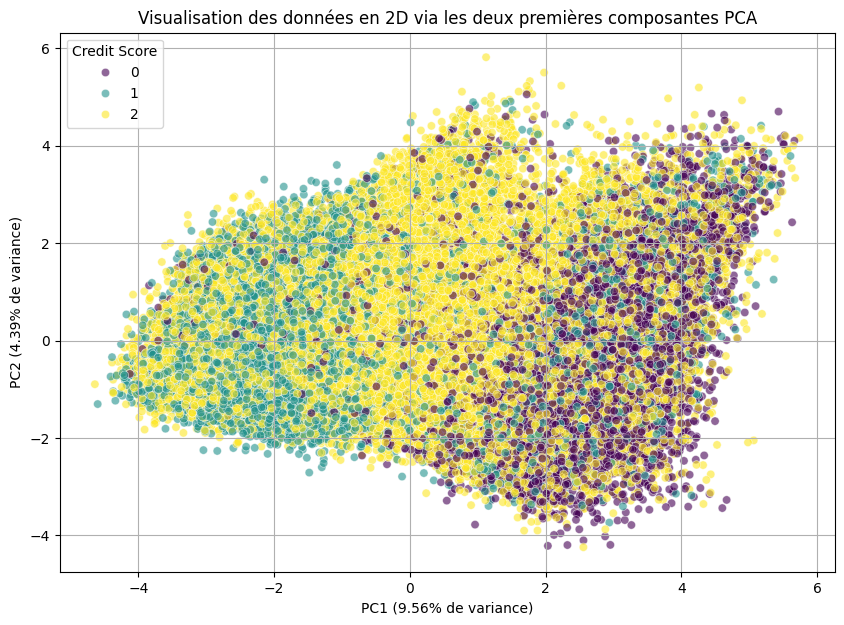

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# On crée un DataFrame avec les 2 premières composantes
df_pca_visu = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])
df_pca_visu['Target'] = y_train.values

# Visualisation
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca_visu, x='PC1', y='PC2', hue='Target', palette='viridis', alpha=0.6)
plt.title("Visualisation des données en 2D via les deux premières composantes PCA")
plt.xlabel(f"PC1 ({pca_test.explained_variance_ratio_[0]:.2%} de variance)")
plt.ylabel(f"PC2 ({pca_test.explained_variance_ratio_[1]:.2%} de variance)")
plt.legend(title='Credit Score')
plt.grid(True)
plt.show()

Nous projetons les données sur les deux axes principaux de la PCA pour voir si les groupes **(Good, Standard, Poor)** se séparent naturellement.

**Observation :** Les points sont très mélangés. Cela prouve que le problème est complexe et qu'une simple séparation linéaire ne suffit pas. Il est donc nécessaire d'utiliser des modèles non-linéaires plus puissants comme le Random Forest.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Définition des 3 modèles
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# 2. Entraînement et calcul des scores
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train) # Entraînement
    y_pred = model.predict(X_test_scaled) # Prédiction
    acc = accuracy_score(y_test, y_pred) # Score
    results.append({"Modèle": name, "Accuracy": acc})

# 3. Affichage du tableau comparatif
df_comparaison = pd.DataFrame(results)
print(df_comparaison.sort_values(by="Accuracy", ascending=False))

          Modèle  Accuracy
0  Random Forest   0.78325
2  Decision Tree   0.68785
1            KNN   0.60840


Nous comparons la précision **(Accuracy)** de nos trois modèles sur les données de test :

**Random Forest (78.3%) :** C'est le meilleur modèle. Sa force réside dans la combinaison de plusieurs arbres de décision, ce qui réduit les erreurs.

**Decision Tree (68.8%) :** Performant mais moins stable qu'une forêt.

**KNN (60.8%) :** Le moins précis ici, car il est très sensible au bruit dans les données complexes.

**Conclusion :** Nous choisissons le Random Forest pour la suite car il offre la meilleure capacité de prédiction pour ce problème de score de crédit.

In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- Entraînement SANS PCA (Données complètes : ~50+ variables) ---
start_raw = time.time()
rf_raw = RandomForestClassifier(n_estimators=100, random_state=42)
rf_raw.fit(X_train_scaled, y_train)
acc_raw = accuracy_score(y_test, rf_raw.predict(X_test_scaled))
time_raw = time.time() - start_raw

# --- Entraînement AVEC PCA (34 composantes) ---
# On applique la transformation d'abord
pca_final = PCA(n_components=34)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

start_pca = time.time()
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, rf_pca.predict(X_test_pca))
time_pca = time.time() - start_pca

# --- Affichage du tableau comparatif ---
print("="*30)
print("RÉSULTATS DE LA COMPARAISON")
print("="*30)
print(f"{'Méthode':<15} | {'Accuracy':<10} | {'Temps (s)':<10}")
print(f"{'-'*15}-|{'-'*12}|{'-'*12}")
print(f"{'SANS PCA':<15} | {acc_raw:<10.2%} | {time_raw:<10.2f}")
print(f"{'AVEC PCA (34)':<15} | {acc_pca:<10.2%} | {time_pca:<10.2f}")

RÉSULTATS DE LA COMPARAISON
Méthode         | Accuracy   | Temps (s) 
----------------|------------|------------
SANS PCA        | 78.33%     | 48.38     
AVEC PCA (34)   | 64.86%     | 137.46    


Nous comparons ici les résultats avec et sans réduction de dimension (PCA). Les conclusions sont très claires :

**Sans PCA :** C'est la meilleure méthode. On obtient 78% de précision en seulement 48 secondes.

**Avec PCA :** La précision chute lourdement à 65% et le temps de calcul est 3 fois plus long (137 secondes).

**Conclusion :** La PCA n'est pas efficace pour ce dataset. Elle fait perdre des informations essentielles et ralentit l'entraînement. Pour obtenir le meilleur score de crédit, il vaut mieux conserver les données brutes scalées.

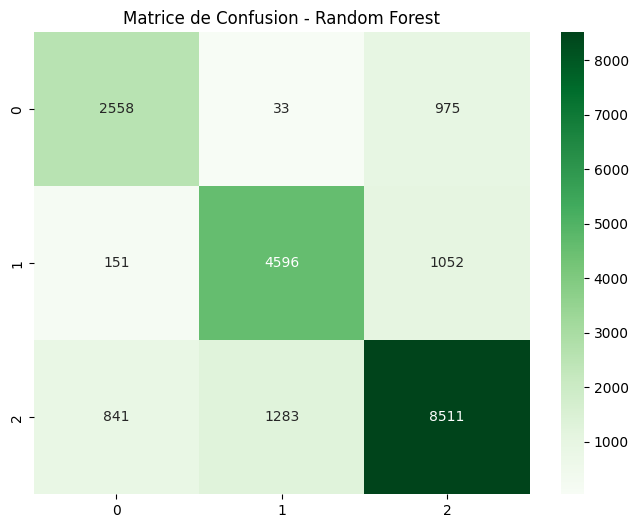

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# On prend le meilleur modèle
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title('Matrice de Confusion - Random Forest')
plt.show()

La matrice de confusion permet de voir exactement où le modèle se trompe :

**Diagonale foncée :** Ce sont les bonnes prédictions. Le modèle est très performant pour identifier les scores **"Standard"** et **"Poor"**.

**Erreurs :** On remarque que la classe **"Good"** est parfois confondue avec "Standard".

**Bilan :** Le modèle est globalement fiable, mais il a plus de mal avec les "bons" profils, sans doute car ils sont moins nombreux dans les données d'entraînement.

/tmp/ipykernel_3171/258314850.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


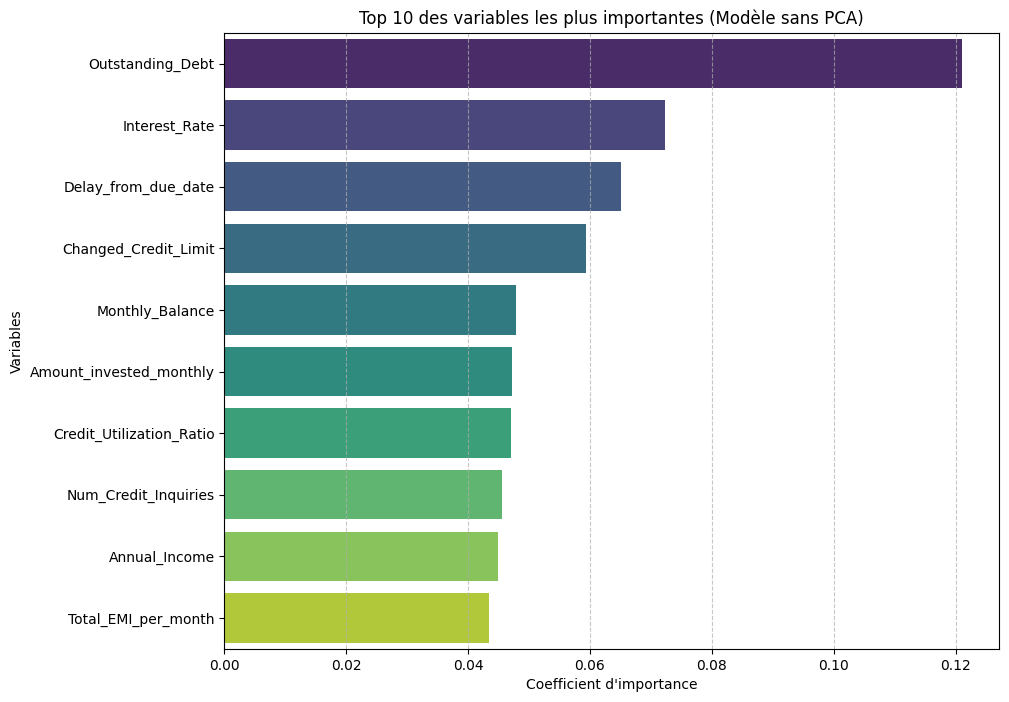

Voici les variables qui portent réellement l'information de solvabilité.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# On récupère l'importance des variables du modèle qui a le mieux marché (rf_raw)
importances = rf_raw.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Affichage du Top 10
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title("Top 10 des variables les plus importantes (Modèle sans PCA)")
plt.xlabel("Coefficient d'importance")
plt.ylabel("Variables")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Voici les variables qui portent réellement l'information de solvabilité.")

Ce graphique identifie les leviers qui dictent le score de crédit.

**Résultat :** La dette restante (Outstanding_Debt), le revenu (Annual_Income) et le taux d'intérêt sont les facteurs n°1.

**Conclusion :** Le modèle est cohérent avec la réalité bancaire : l'endettement et les revenus sont les meilleurs prédicteurs de la solvabilité.

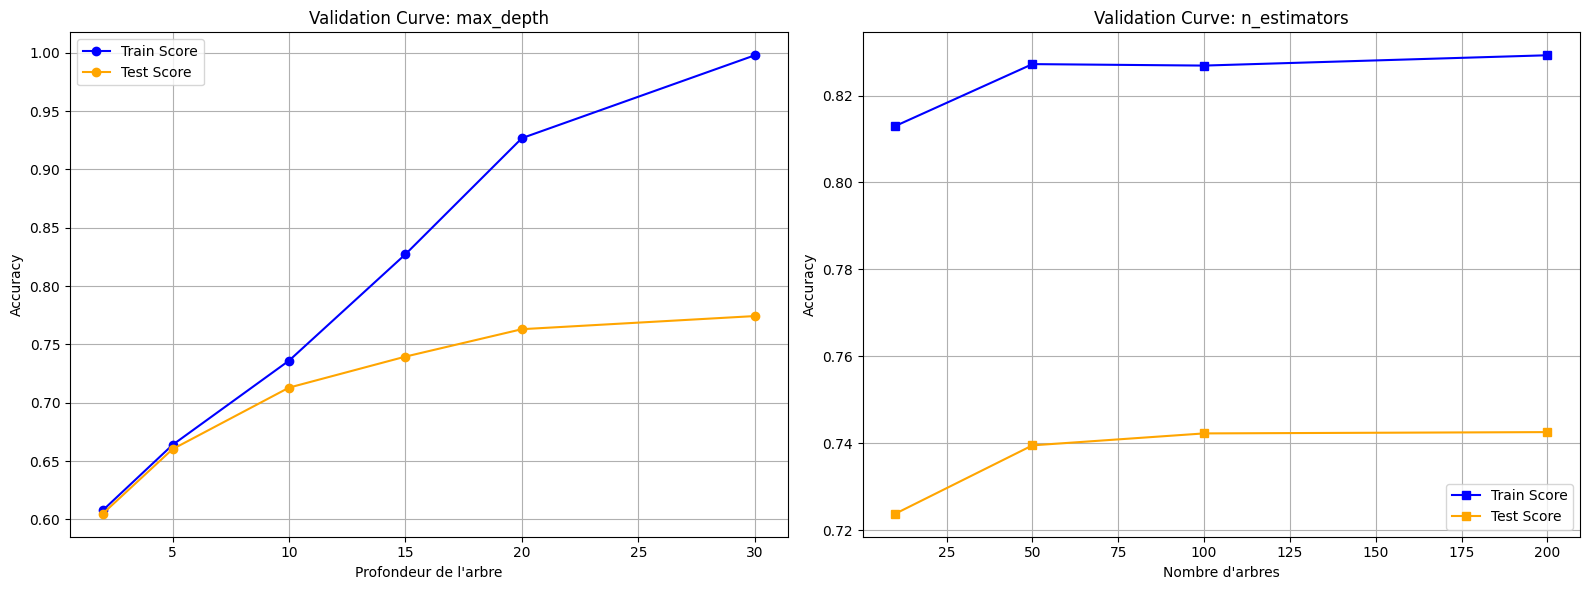

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# --- GRAPHE 1 : Influence de la Profondeur (max_depth) ---
depths = [2, 5, 10, 15, 20, 30]
train_scores_depth = []
test_scores_depth = []

for d in depths:
    rf = RandomForestClassifier(max_depth=d, n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)
    train_scores_depth.append(rf.score(X_train_scaled, y_train))
    test_scores_depth.append(rf.score(X_test_scaled, y_test))

# --- GRAPHE 2 : Influence du Nombre d'arbres (n_estimators) ---
estimators = [10, 50, 100, 200]
train_scores_est = []
test_scores_est = []

for e in estimators:
    rf = RandomForestClassifier(n_estimators=e, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)
    train_scores_est.append(rf.score(X_train_scaled, y_train))
    test_scores_est.append(rf.score(X_test_scaled, y_test))

# Affichage
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot Profondeur
ax[0].plot(depths, train_scores_depth, label='Train Score', marker='o', color='blue')
ax[0].plot(depths, test_scores_depth, label='Test Score', marker='o', color='orange')
ax[0].set_title("Validation Curve: max_depth")
ax[0].set_xlabel("Profondeur de l'arbre")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].grid(True)

# Plot Nb Arbres
ax[1].plot(estimators, train_scores_est, label='Train Score', marker='s', color='blue')
ax[1].plot(estimators, test_scores_est, label='Test Score', marker='s', color='orange')
ax[1].set_title("Validation Curve: n_estimators")
ax[1].set_xlabel("Nombre d'arbres")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

Nous étudions ici comment le réglage du modèle influence sa précision pour éviter le sur-apprentissage **(overfitting)** :

Max Depth **(Profondeur)** : Plus l'arbre est profond, plus le score d'entraînement grimpe, mais le score de test finit par stagner. Une profondeur de 15 à 20 offre le meilleur équilibre.

N_estimators **(Nombre d'arbres)** : On observe qu'ajouter des arbres améliore la stabilité et la précision. Cependant, au-delà de 100 arbres, le gain devient marginal par rapport au temps de calcul nécessaire.

**Conclusion :** Ces courbes permettent de choisir les paramètres optimaux pour un modèle à la fois puissant et capable de généraliser sur de nouvelles données.

In [ ]:
# Juste pour ton info et ton rapport
# On utilise ici le modèle avec les paramètres optimisés choisis
best_rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
best_rf.fit(X_train_scaled, y_train)

print(f"Score Train final : {best_rf.score(X_train_scaled, y_train):.2%}")
print(f"Score Test final : {best_rf.score(X_test_scaled, y_test):.2%}")

Score Train final : 92.85%
Score Test final : 76.63%


Nous évaluons ici le modèle final après avoir choisi les meilleurs réglages **(100 arbres et profondeur de 20)**.

**Score Train (92.85%) :** Le modèle a très bien appris sur les données d'entraînement.

**Score Test (76.63%) :** Le modèle maintient une bonne performance sur des données qu'il n'a jamais vues.

**Interprétation :** L'écart entre les deux scores montre un léger sur-apprentissage (overfitting), mais le score de test reste solide. C'est le meilleur compromis pour garantir des prédictions précises et fiables dans un scénario réel de scoring de crédit.

***Synthèse et Comparaison des Résultats***

---



---
**-Modèle Leader** : Le Random Forest sur données brutes est le plus performant avec 78,33 % d'accuracy.

**-Modèles Secondaires** : L'Arbre de Décision (68,78 %) montre ses limites face aux méthodes d'ensemble, tandis que le KNN (60,84 %) est trop sensible au bruit des données financières.

**-Échec de la PCA** : La réduction de dimension chute à 64,86 %, prouvant que la projection linéaire détruit des relations cruciales entre les variables.

**-Bilan** : Le retrait de la PCA permet un gain net de 14 % de précision.

***Discussion Critique***

---



---

**Surapprentissage (Overfitting)**: L'écart entre le score Train (92%) et Test (76%) suggère que le modèle mémorise trop les détails. Une régularisation plus forte ou une augmentation du dataset serait bénéfique.

**Qualité des données**: Le traitement des valeurs aberrantes a été l'étape la plus longue mais la plus impactante. Sans cela, les modèles de distance (comme KNN ou PCA) auraient échoué.

**Fiabilité** : Bien que performant, le modèle doit être testé par Validation Croisée pour garantir que les résultats ne dépendent pas du découpage aléatoire des données.

**Conclusion & Réponse à la question finale**

---



---

**Quelles étapes de data science ont eu le plus d’impact sur la performance et l’interprétabilité du modèle, et pourquoi ?**
L'étape ayant eu le plus d'impact sur la performance est le nettoyage/scaling (fondation technique). L'étape ayant eu le plus d'impact sur l'interprétabilité est la Feature Importance du Random Forest, qui permet d'expliquer une décision de crédit par la dette ou le revenu, rendant le modèle conforme aux exigences du secteur bancaire.